In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the data
file_path = 'Processed_Garment_Production.XLSX'  # Ensure the file exists in the working directory
sheet_name = 'Summary - Jan to Jun'

try:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    exit()
except Exception as e:
    print(f"Error loading file: {e}")
    exit()


### *Feature Engineering*


### overview of the data

In [41]:
print(f"Dataset shape: {df.shape}")
print("\nData types:")
print(df.dtypes)
print("\nSummary statistics:")
print(df.describe())

Dataset shape: (154, 23)

Data types:
Month                           object
DEPT                            object
ORDER DATE              datetime64[ns]
STYLE/FIT                       object
WASH/COLOR                      object
QNTY                           float64
FOB                            float64
SHIP DATE               datetime64[ns]
PCD                     datetime64[ns]
SHIPPED QNTY                     int64
SHORT/EXCESS                   float64
Customer Ship Date      datetime64[ns]
Production Unit                 object
Order_Year                       int64
Order_Month                      int64
Ship_Year                        int64
Ship_Month                       int64
Production_Lead_Time             int64
Shipping_Lead_Time               int64
Total_Order_Value              float64
Shortage_Flag                    int64
Color_Complexity                object
Season                          object
dtype: object

Summary statistics:
                          ORDE

### Department Analysis 

C:\Users\acer\AppData\Local\Temp\ipykernel_9388\141807944.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='DEPT', order=df['DEPT'].value_counts().index, palette="coolwarm")


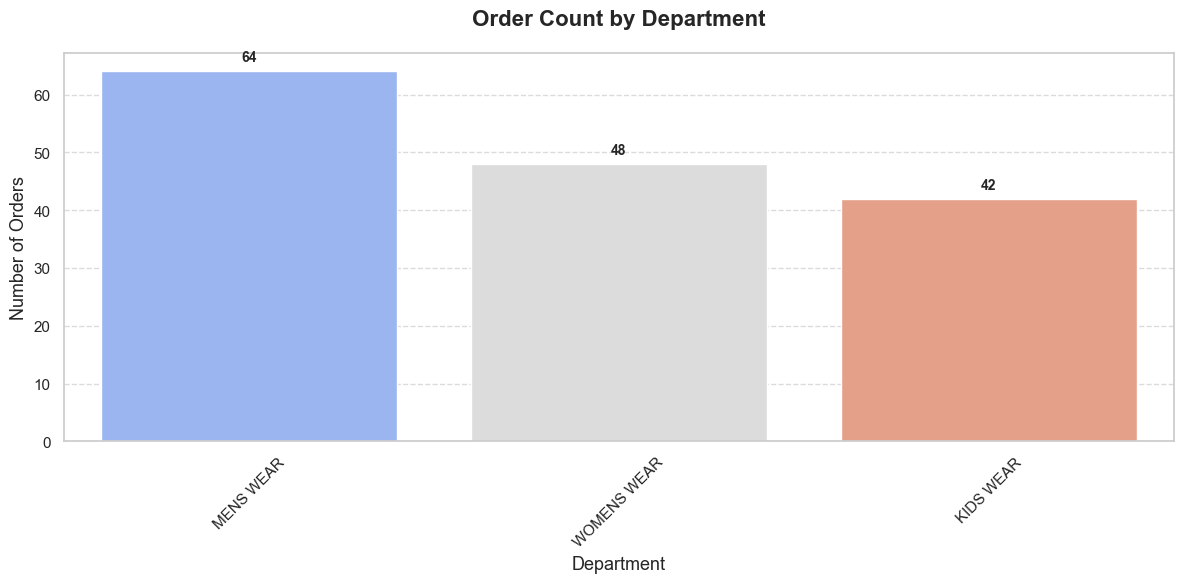

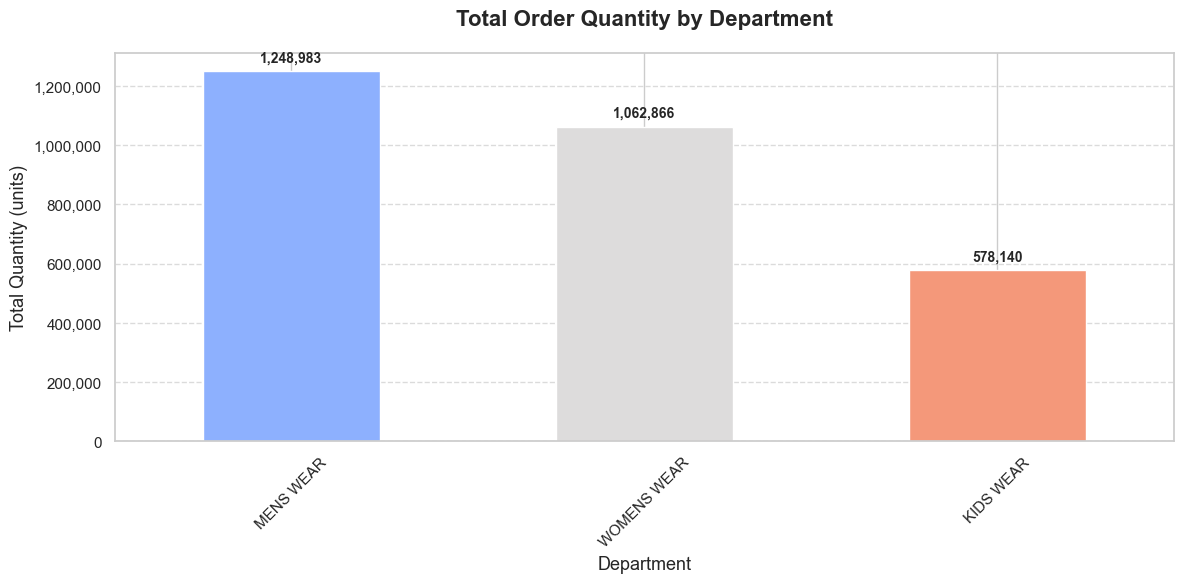

In [50]:

import matplotlib.ticker as mtick

sns.set_theme(style="whitegrid")  # Apply a clean theme

# Order Count by Department
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='DEPT', order=df['DEPT'].value_counts().index, palette="coolwarm")

plt.title('Order Count by Department', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Department', fontsize=13)
plt.ylabel('Number of Orders', fontsize=13)
plt.xticks(rotation=45, fontsize=11)

# Add exact counts on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add subtle grid
plt.tight_layout()
plt.show()

# ---- Total Quantity by Department ----
plt.figure(figsize=(12, 6))
dept_qty = df.groupby('DEPT')['QNTY'].sum().sort_values(ascending=False)
ax = dept_qty.plot(kind='bar', color=sns.color_palette("coolwarm", len(dept_qty)))

plt.title('Total Order Quantity by Department', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Department', fontsize=13)
plt.ylabel('Total Quantity (units)', fontsize=13)
plt.xticks(rotation=45, fontsize=11)

# Add exact values on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

# Format y-axis labels to include commas
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Style/Fit Analysis

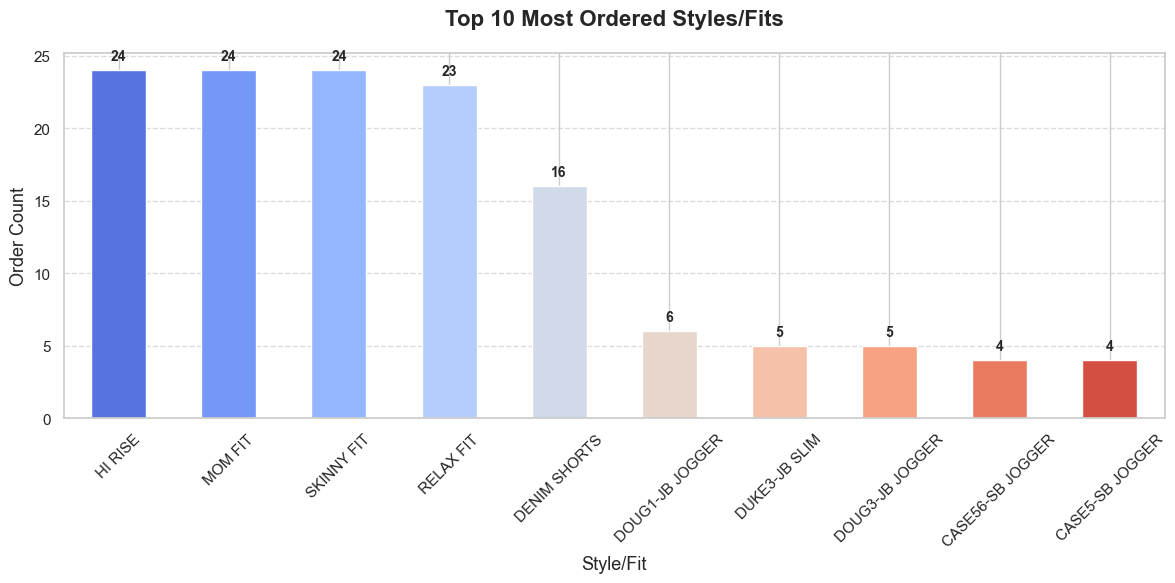

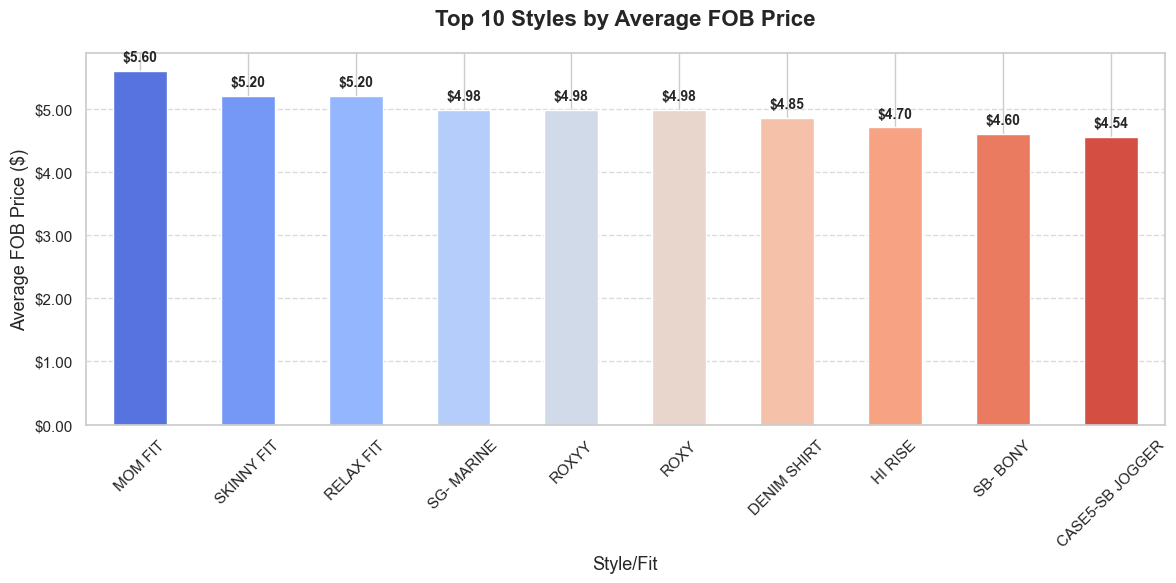

In [43]:
sns.set_theme(style="whitegrid")  # Apply a clean theme

# ---- Top 10 Most Ordered Styles/Fits ----
plt.figure(figsize=(12, 6))
top_styles = df['STYLE/FIT'].value_counts().head(10)
ax = top_styles.plot(kind='bar', color=sns.color_palette("coolwarm", len(top_styles)))

plt.title('Top 10 Most Ordered Styles/Fits', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Style/Fit', fontsize=13)
plt.ylabel('Order Count', fontsize=13)
plt.xticks(rotation=45, fontsize=11)

# Add exact values on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ---- Top 10 Styles by Average FOB Price ----
plt.figure(figsize=(12, 6))
style_fob = df.groupby('STYLE/FIT')['FOB'].mean().sort_values(ascending=False).head(10)
ax = style_fob.plot(kind='bar', color=sns.color_palette("coolwarm", len(style_fob)))

plt.title('Top 10 Styles by Average FOB Price', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Style/Fit', fontsize=13)
plt.ylabel('Average FOB Price ($)', fontsize=13)
plt.xticks(rotation=45, fontsize=11)

# Add exact values on top of bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}',  
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

# Format y-axis labels as currency
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.2f}'))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Time Series Analysis

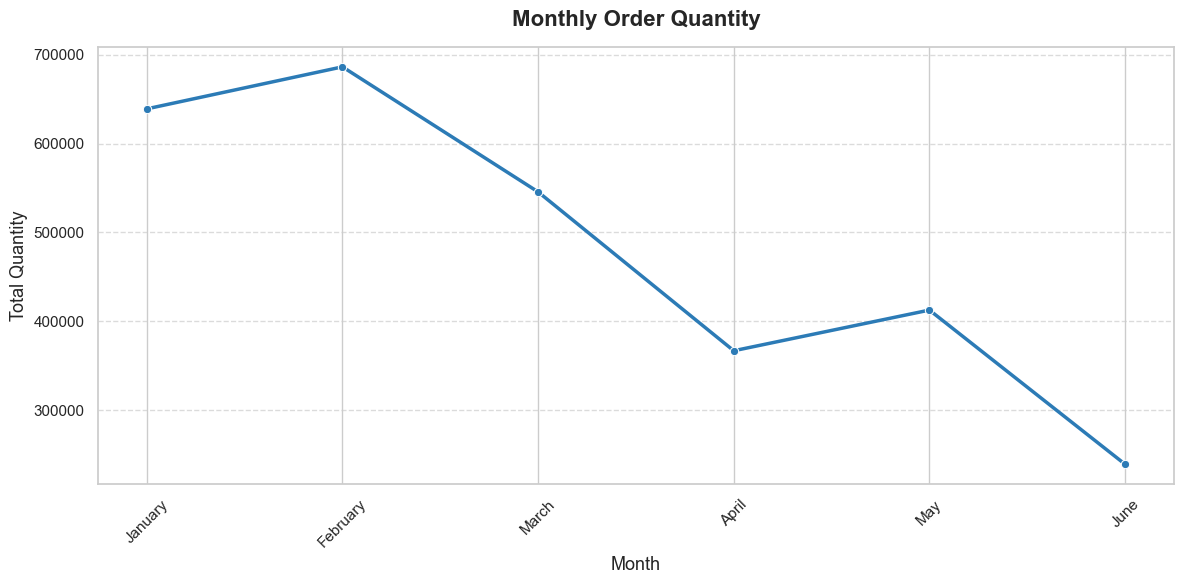

Plot successfully updated with aggregated monthly data.


C:\Users\acer\AppData\Local\Temp\ipykernel_9388\2222699215.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='DEPT', y='Production_Lead_Time', palette="coolwarm")


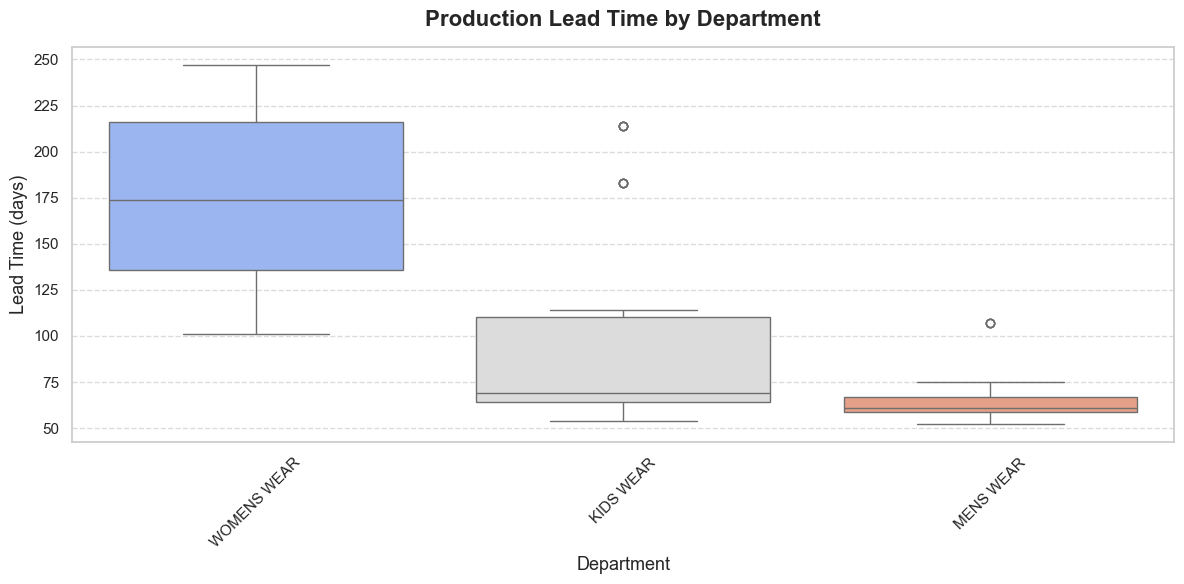

In [44]:

sns.set_theme(style="whitegrid")  # Apply a clean and professional theme

# Define the correct order of months
month_order = ["January", "February", "March", "April", "May", "June"]

# Ensure 'Month' and 'QNTY' columns exist
if 'Month' in df.columns and 'QNTY' in df.columns:
    df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

    # Group by month and sum the quantities
    monthly_data = df.groupby("Month", observed=False)["QNTY"].sum().reset_index()

    # --- Monthly Order Quantity Line Chart ---
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=monthly_data, x="Month", y="QNTY", marker="o", linewidth=2.5, color="#2C7BB6")

    plt.title('Monthly Order Quantity', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Month', fontsize=13)
    plt.ylabel('Total Quantity', fontsize=13)
    plt.xticks(rotation=45, fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Subtle grid for readability
    plt.tight_layout()
    plt.show()

    print("Plot successfully updated with aggregated monthly data.")
else:
    print("Error: 'Month' or 'QNTY' column not found in the dataset!")


# --- Production Lead Time by Department (Boxplot) ---
if 'DEPT' in df.columns and 'Production_Lead_Time' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='DEPT', y='Production_Lead_Time', palette="coolwarm")

    plt.title('Production Lead Time by Department', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Department', fontsize=13)
    plt.ylabel('Lead Time (days)', fontsize=13)
    plt.xticks(rotation=45, fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Grid for better readability
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'DEPT' or 'Production_Lead_Time' column not found in the dataset!")

### Shortage percentage by department


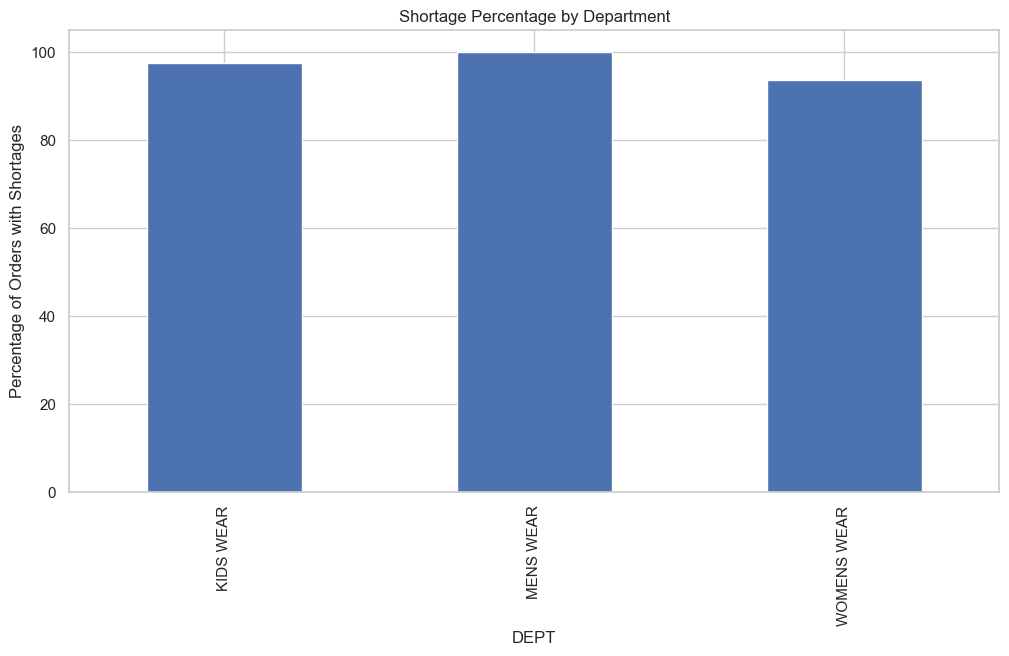

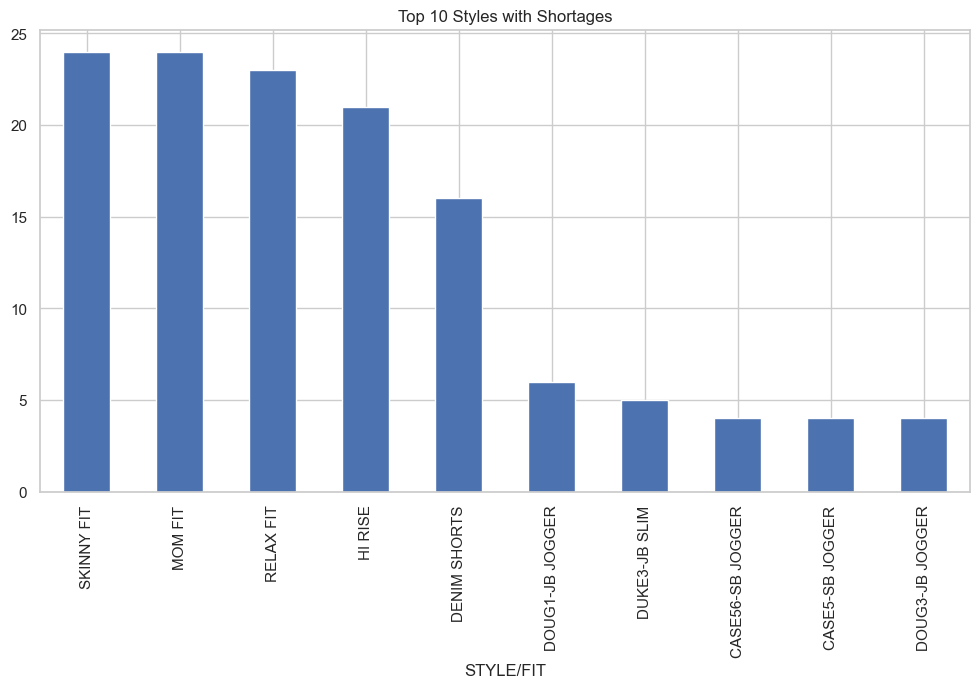

In [45]:
shortage_pct = df.groupby('DEPT')['Shortage_Flag'].mean() * 100
shortage_pct.plot(kind='bar', figsize=(12, 6))
plt.title('Shortage Percentage by Department')
plt.ylabel('Percentage of Orders with Shortages')
plt.show()

# Most problematic styles
problem_styles = df[df['Shortage_Flag'] == 1]['STYLE/FIT'].value_counts().head(10)
problem_styles.plot(kind='bar', figsize=(12, 6))
plt.title('Top 10 Styles with Shortages')
plt.show()

### Production Unit Analysis

C:\Users\acer\AppData\Local\Temp\ipykernel_9388\2208469180.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=unit_efficiency.index, y=unit_efficiency.values, palette="coolwarm")


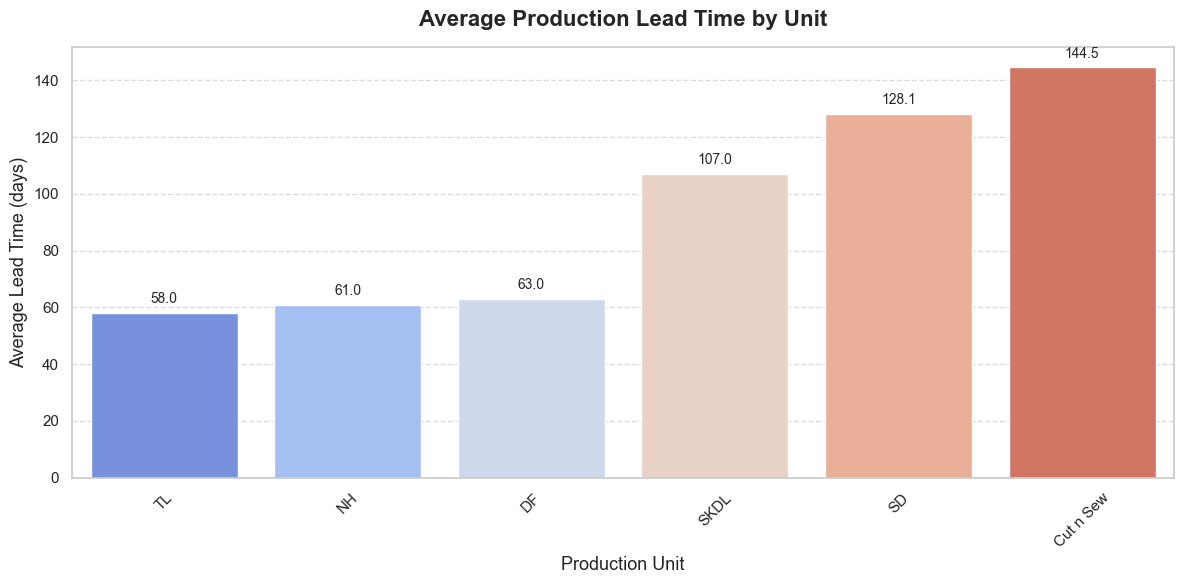

In [46]:
sns.set_theme(style="whitegrid")  # Apply Seaborn theme for a clean look

# --- Production Unit Efficiency Analysis ---
if 'Production Unit' in df.columns and 'Production_Lead_Time' in df.columns:
    unit_efficiency = df.groupby('Production Unit')['Production_Lead_Time'].mean().sort_values()

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=unit_efficiency.index, y=unit_efficiency.values, palette="coolwarm")

    plt.title('Average Production Lead Time by Unit', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Production Unit', fontsize=13)
    plt.ylabel('Average Lead Time (days)', fontsize=13)
    plt.xticks(rotation=45, fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Subtle grid for readability

    # Annotate each bar with its exact value
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("Error: 'Production Unit' or 'Production_Lead_Time' column not found in the dataset!")

### Correlation Analysis

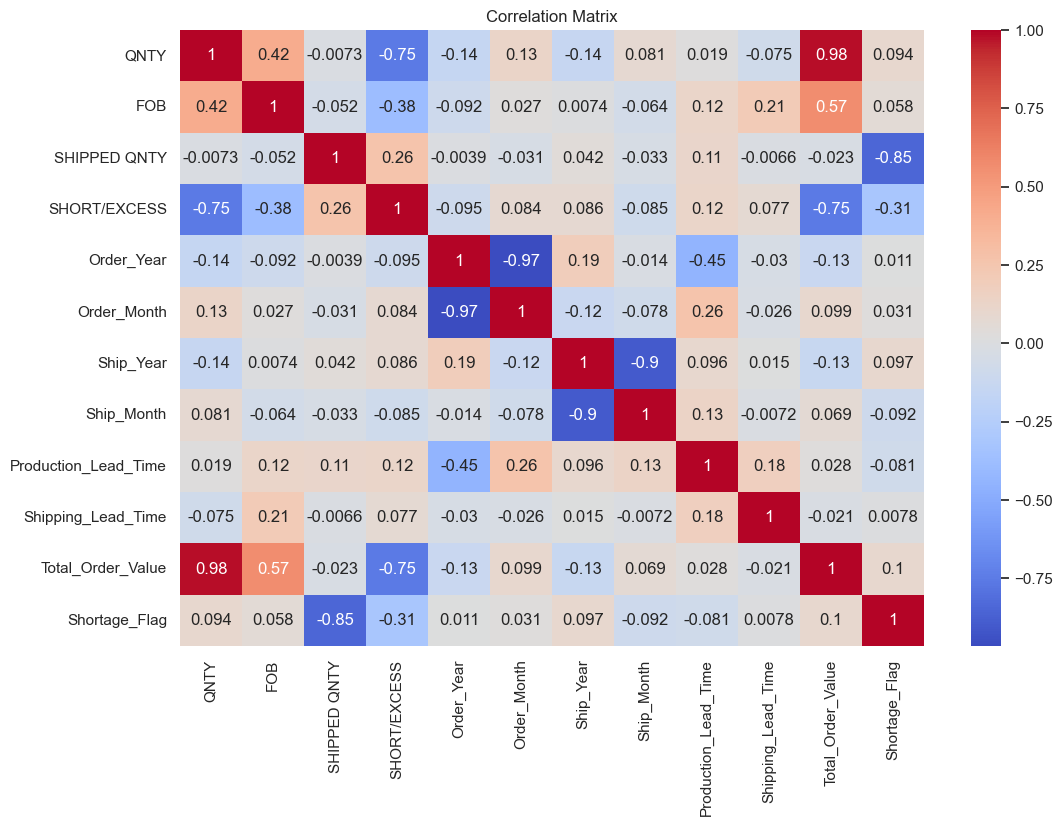

In [47]:
# Select numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [48]:
df

,Month,DEPT,ORDER DATE,STYLE/FIT,WASH/COLOR,QNTY,FOB,SHIP DATE,PCD,SHIPPED QNTY,...,Order_Year,Order_Month,Ship_Year,Ship_Month,Production_Lead_Time,Shipping_Lead_Time,Total_Order_Value,Shortage_Flag,Color_Complexity,Season
0,January,WOMENS WEAR,2024-09-19,HI RISE,BLACK,26171.0,4.70,2024-12-29,2024-12-04,0,...,2024,9,2024,12,101,8,123003.7,1,Simple,Winter
1,January,WOMENS WEAR,2024-09-19,HI RISE,LT INDIGO,24333.0,4.70,2024-12-29,2024-12-04,0,...,2024,9,2024,12,101,8,114365.1,1,Complex,Winter
2,January,WOMENS WEAR,2024-09-19,HI RISE,DK INDIGO,31704.0,4.70,2024-12-29,2024-12-04,0,...,2024,9,2024,12,101,8,149008.8,1,Complex,Winter
3,January,WOMENS WEAR,2024-09-19,HI RISE,WHITE,0.0,4.70,2024-12-29,2024-12-04,0,...,2024,9,2024,12,101,8,0.0,0,Simple,Winter
4,January,WOMENS WEAR,2024-09-19,MOM FIT,BEIGE,26000.0,5.60,2024-12-31,2024-12-06,0,...,2024,9,2024,12,103,8,145600.0,1,Simple,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,May,MENS WEAR,2025-03-06,SKINNY FIT,LT GREY,19393.0,5.20,2025-04-27,2025-04-02,0,...,2025,3,2025,4,52,8,100843.6,1,Complex,Summer
150,May,MENS WEAR,2025-02-11,DENIM SHORTS,LT INDIGO,4970.0,3.65,2025-04-27,2025-01-31,0,...,2025,2,2025,4,75,8,18140.5,1,Complex,Summer
151,May,MENS WEAR,2025-02-11,DENIM SHORTS,BLACK,4970.0,3.65,2025-04-27,2025-01-31,0,...,2025,2,2025,4,75,8,18140.5,1,Simple,Summer
152,May,MENS WEAR,2025-02-11,DENIM SHORTS,INDIGO,4970.0,3.65,2025-04-27,2025-01-31,0,...,2025,2,2025,4,75,8,18140.5,1,Complex,Summer


In [49]:

# Define the output file path
output_file = "Processed_Garment_Production2.xlsx"

# Save the DataFrame to an Excel file
df.to_excel(output_file, index=False)

print(f"Data successfully saved to {output_file}")


Data successfully saved to Processed_Garment_Production2.xlsx
